# YOLO baseline evaluation — same protocol as A4

Evaluates **yolov8m-seg.pt** and **yolo26n.pt** through the exact pycocotools
`COCOeval` pipeline A4 used, on the exact same validation split (SEED=42,
VAL_SIZE=0.15, MultilabelStratifiedShuffleSplit → 1,400 val images).

Outputs, mirroring Chapter 6 of the report:
- Table 6.5 equivalent: overall bbox/mask AP, AP50, AP75, AR@100
- Table 6.6 equivalent: per-class bbox AP / AP50 / AP75
- Table 6.7 equivalent: threshold sweep (TP, FP, FN, Precision, Recall, F1, FP/img)
- Figures 6.5/6.6 equivalent: confusion matrices at conf 0.05 and 0.10
- Table 6.8 equivalent: best threshold per class
- Table 6.9 equivalent: weak-class error taxonomy
- Table 6.10 equivalent: final comparison row for both YOLO models vs A4

**Attach `anonymized-dataset` and the YOLO weights** (`yolov8m-seg.pt`, `yolo26n.pt`) as
Kaggle inputs, then run top to bottom.

## 1 — Install dependencies

In [1]:
%pip install -q ultralytics pycocotools iterative-stratification

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.9 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


## 2 — Imports and seed

In [2]:
import json
import math
import os
import random
import warnings
from collections import defaultdict, Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image, ImageDraw, ImageFile
import cv2
import matplotlib.pyplot as plt

from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.preprocessing import MultiLabelBinarizer

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import pycocotools.mask as mask_utils

from ultralytics import YOLO

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
DEVICE: cuda


## 3 — Configuration (must match A4 exactly)

These values come from `brr.ipynb` (the A4 resume-v5 run that produced the final
report numbers). Do not change them — the whole point of this notebook is to
evaluate YOLO on the same split A4 was evaluated on.

In [3]:
# Dataset roots (first one that exists wins)
POSSIBLE_ROOTS = [
    Path("/kaggle/input/anonymized-dataset"),
    Path("/kaggle/input/datasets/anonymous-user/anonymized-dataset"),
]
DATASET_ROOT = None
for p in POSSIBLE_ROOTS:
    if p.exists():
        DATASET_ROOT = p
        break
if DATASET_ROOT is None:
    raise FileNotFoundError("Could not find anonymized-dataset under /kaggle/input.")

IMAGES_DIR       = DATASET_ROOT / "train"
ANNOTATIONS_PATH = DATASET_ROOT / "train" / "_annotations.coco.json"

# A4 split params
VAL_SIZE   = 0.15
IMAGE_SIZE = 672    # bbox eval resolution
MASK_EVAL  = 168    # segm eval resolution (per the report)

# Class filter (same normalization rules as A4)
KEEP_CLASS_TARGETS = [
    "bone level resorption",
    "dental crown",
    "dental filling",
    "dental implant",
    "mandibular nerve",
    "maxillary sinus",
    "periodental infection",
    "periodontal infection",
    "root canal traitement",
    "tooth decay",
    "wisdom tooth",
]

# Output dir
WORK_DIR = Path("/kaggle/working/yolo_baseline_eval")
WORK_DIR.mkdir(parents=True, exist_ok=True)

# YOLO checkpoints — point at whatever you attached
# EDIT THESE PATHS to point at your dental-trained best.pt
# (The stock Ultralytics weights have COCO 80 classes — they will NOT work.)
YOLO_CANDIDATE_PATHS = {
    "yolov8m-seg": [
        # ---- add your dental-trained checkpoint path(s) here, most-preferred first ----
        Path("/kaggle/input/datasets/anonymous-user/anonymized-yolo-checkpoints/best.pt"),
        Path("/kaggle/input/datasets/anonymous-user/anonymized-yolo-best/best.pt"),
        Path("/kaggle/input/datasets/anonymous-user/anonymized-yolo-best/best.pt"),
        # ---- stock fallbacks (for paths only — these WILL fail the class check) ----
        Path("/kaggle/input/yolo-seg-corrected-bundle/yolov8m-seg.pt"),
        Path("/kaggle/input/yolo-weights/yolov8m-seg.pt"),
        Path("/kaggle/input/datasets/anonymous-user/yolo-weights/yolov8m-seg.pt"),
        Path("/kaggle/input/datasets/anonymous-user/anonymized-yolo-checkpoints/yolov8m-seg.pt"),
    ],
    "yolo26n": [
        Path("/kaggle/input/yolo-seg-corrected-bundle/yolo26n.pt"),
        Path("/kaggle/input/yolo-weights/yolo26n.pt"),
        Path("/kaggle/input/datasets/anonymous-user/yolo-weights/yolo26n.pt"),
        Path("/kaggle/input/notebooks/anonymous-user/yolo-segs/yolo26n.pt"),
    ],
}

def resolve_yolo(tag):
    for p in YOLO_CANDIDATE_PATHS[tag]:
        if p.exists():
            return p
    return None

print("DATASET_ROOT:", DATASET_ROOT)
print("yolov8m-seg :", resolve_yolo("yolov8m-seg"))
print("yolo26n     :", resolve_yolo("yolo26n"))

DATASET_ROOT: /kaggle/input/datasets/anonymous-user/anonymized-dataset
yolov8m-seg : /kaggle/input/datasets/anonymous-user/anonymized-yolo-checkpoints/best.pt
yolo26n     : /kaggle/input/notebooks/anonymous-user/yolo-segs/yolo26n.pt


## 4 — Replicate the A4 validation split

Copy of the A4 dataset-prep logic (from `brr.ipynb`). Produces the same
`val_images_df` / `val_ann_df` the A4 checkpoint was evaluated on.

In [4]:
with open(ANNOTATIONS_PATH, "r", encoding="utf-8") as f:
    coco_raw = json.load(f)

images_df = pd.DataFrame(coco_raw["images"]).rename(columns={"id": "image_id"}).copy()
ann_df    = pd.DataFrame(coco_raw["annotations"]).rename(columns={"id": "annotation_id"}).copy()
cat_df    = pd.DataFrame(coco_raw["categories"]).rename(
    columns={"id": "category_id", "name": "category_name"}).copy()

def norm_name(x):
    x = str(x).strip().lower()
    x = x.replace("_", " ").replace("-", " ")
    return " ".join(x.split())

cat_df["category_name_norm"] = cat_df["category_name"].apply(norm_name)
keep_targets = {norm_name(x) for x in KEEP_CLASS_TARGETS}

selected_cat_df = cat_df.loc[cat_df["category_name_norm"].isin(keep_targets)].copy()
selected_category_ids = sorted(selected_cat_df["category_id"].astype(int).tolist())

def resolve_image_path(file_name):
    file_name = str(file_name)
    for c in [DATASET_ROOT/file_name, IMAGES_DIR/file_name, IMAGES_DIR/Path(file_name).name]:
        if c.exists():
            return c
    return IMAGES_DIR/Path(file_name).name

images_df["image_path"]  = images_df["file_name"].apply(resolve_image_path)
images_df["file_exists"] = images_df["image_path"].apply(lambda p: Path(p).exists())

bbox_df = pd.DataFrame(
    ann_df["bbox"].apply(lambda b: b if isinstance(b, list) and len(b) == 4 else [np.nan]*4).tolist(),
    columns=["x", "y", "w", "h"])
for c in ["x", "y", "w", "h"]:
    bbox_df[c] = pd.to_numeric(bbox_df[c], errors="coerce")
ann_df = pd.concat([ann_df, bbox_df], axis=1)

for c in ["annotation_id", "image_id", "category_id", "area"]:
    if c in ann_df.columns:
        ann_df[c] = pd.to_numeric(ann_df[c], errors="coerce")
for c in ["width", "height"]:
    if c in images_df.columns:
        images_df[c] = pd.to_numeric(images_df[c], errors="coerce")

ann_df = ann_df.merge(
    images_df[["image_id", "width", "height", "image_path", "file_exists", "file_name"]],
    on="image_id", how="left")
ann_df = ann_df.merge(
    cat_df[["category_id", "category_name", "category_name_norm"]],
    on="category_id", how="left")

ann_df = ann_df.loc[ann_df["file_exists"] == True].copy()
ann_df = ann_df.loc[ann_df["category_id"].isin(selected_category_ids)].copy()

def polygon_area_xy(points):
    if len(points) < 6: return 0.0
    xs = np.array(points[0::2], dtype=float); ys = np.array(points[1::2], dtype=float)
    return 0.5 * abs(np.dot(xs, np.roll(ys,-1)) - np.dot(ys, np.roll(xs,-1)))

def choose_best_polygon(segmentation):
    if not isinstance(segmentation, list) or len(segmentation) == 0: return None
    cands = []
    for poly in segmentation:
        if not isinstance(poly, list): continue
        if len(poly) < 6 or len(poly) % 2 != 0: continue
        a = polygon_area_xy(poly)
        if a > 0: cands.append((a, poly))
    if not cands: return None
    cands.sort(key=lambda x: x[0], reverse=True)
    return cands[0][1]

ann_df["best_polygon"] = ann_df["segmentation"].apply(choose_best_polygon)
ann_df = ann_df.loc[ann_df["best_polygon"].notna()].copy()

ann_df["x"]  = ann_df["x"].clip(lower=0)
ann_df["y"]  = ann_df["y"].clip(lower=0)
ann_df["x2"] = (ann_df["x"] + ann_df["w"]).clip(upper=ann_df["width"])
ann_df["y2"] = (ann_df["y"] + ann_df["h"]).clip(upper=ann_df["height"])
ann_df["w"]  = ann_df["x2"] - ann_df["x"]
ann_df["h"]  = ann_df["y2"] - ann_df["y"]

ann_df = ann_df.loc[
    ann_df[["x","y","w","h"]].notna().all(axis=1) &
    (ann_df["w"] > 0) & (ann_df["h"] > 0) &
    (ann_df["width"] > 0) & (ann_df["height"] > 0)
].copy()

present_category_ids = sorted(ann_df["category_id"].dropna().astype(int).unique().tolist())
present_cat_df = (
    selected_cat_df.loc[selected_cat_df["category_id"].isin(present_category_ids)]
    .sort_values("category_id").reset_index(drop=True))

category_id_to_new = {cid: i for i, cid in enumerate(present_cat_df["category_id"].tolist())}
new_to_name = {i: name for i, name in enumerate(present_cat_df["category_name"].tolist())}
ann_df["class_id"] = ann_df["category_id"].map(category_id_to_new)
NC = len(new_to_name)

print(f"Classes (NC={NC}):")
for i, name in new_to_name.items():
    print(f"  [{i}] {name}")

Classes (NC=10):
  [0] Bone level resorption
  [1] Dental crown
  [2] Dental filling
  [3] Dental implant
  [4] Mandibular nerve
  [5] Maxillary sinus
  [6] Periodental infection
  [7] Root canal traitement
  [8] Tooth decay
  [9] Wisdom tooth


In [5]:
# Split (identical to A4 resume-v5)
img_to_classes = ann_df.groupby("image_id")["class_id"].apply(
    lambda s: sorted(set(int(v) for v in s.tolist()))).to_dict()

split_images_df = images_df.loc[images_df["file_exists"]].copy()
split_images_df["labels"] = split_images_df["image_id"].map(img_to_classes)
split_images_df["labels"] = split_images_df["labels"].apply(
    lambda x: x if isinstance(x, list) else [])
split_images_df = split_images_df.loc[
    split_images_df["labels"].apply(len) > 0].reset_index(drop=True)

mlb = MultiLabelBinarizer(classes=list(range(NC)))
Y = mlb.fit_transform(split_images_df["labels"])

msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=SEED)
train_idx, val_idx = next(msss.split(split_images_df, Y))

val_images_df = split_images_df.iloc[val_idx].copy().reset_index(drop=True)
val_image_ids = set(val_images_df["image_id"].tolist())
val_ann_df    = ann_df.loc[ann_df["image_id"].isin(val_image_ids)].copy()

print(f"Val images : {len(val_images_df)}")
print(f"Val objects: {len(val_ann_df)}")
print("\nObjects per class on val:")
for i, name in new_to_name.items():
    n = int((val_ann_df['class_id'] == i).sum())
    print(f"  [{i}] {name:35s}  {n:5d}")

Val images : 1400
Val objects: 13468

Objects per class on val:
  [0] Bone level resorption                  400
  [1] Dental crown                          1210
  [2] Dental filling                        5041
  [3] Dental implant                         168
  [4] Mandibular nerve                        75
  [5] Maxillary sinus                         60
  [6] Periodental infection                  555
  [7] Root canal traitement                 1982
  [8] Tooth decay                           1121
  [9] Wisdom tooth                          2856


## 5 — Build ground-truth COCO object (shared across models)

GT is built twice: once with bbox coords in `IMAGE_SIZE=672` space (for bbox
eval), and once with masks rasterized at `MASK_EVAL=168` and RLE-encoded (for
segm eval). This matches the report's statement: *"masks resized to 168×168 for
memory-efficient COCO-style encoding"*.

In [6]:
def build_coco_gt_bbox():
    '''GT COCO object with boxes in IMAGE_SIZE x IMAGE_SIZE space.'''
    gt_images = []
    gt_annotations = []
    ann_id = 1
    for _, row in val_images_df.iterrows():
        img_id = int(row["image_id"])
        gt_images.append({"id": img_id, "height": IMAGE_SIZE, "width": IMAGE_SIZE,
                          "file_name": str(row["file_name"])})
    for _, r in val_ann_df.iterrows():
        img_id = int(r["image_id"])
        orig_w = float(r["width"]); orig_h = float(r["height"])
        sx = IMAGE_SIZE / orig_w
        sy = IMAGE_SIZE / orig_h
        x = float(r["x"]) * sx
        y = float(r["y"]) * sy
        w = float(r["w"]) * sx
        h = float(r["h"]) * sy
        cat_new = int(r["class_id"]) + 1   # COCOeval wants 1-indexed
        gt_annotations.append({
            "id": ann_id, "image_id": img_id, "category_id": cat_new,
            "bbox": [x, y, w, h], "area": float(w * h), "iscrowd": 0,
        })
        ann_id += 1
    categories = [{"id": i+1, "name": new_to_name[i]} for i in range(NC)]
    gt_dict = {"images": gt_images, "annotations": gt_annotations, "categories": categories}
    coco_gt = COCO()
    coco_gt.dataset = gt_dict
    coco_gt.createIndex()
    return coco_gt

def polygon_to_mask_at_size(poly, orig_w, orig_h, out_size):
    '''Rasterize polygon at original size, resize to out_size x out_size.'''
    m = Image.new("L", (int(orig_w), int(orig_h)), 0)
    pts = [(float(poly[i]), float(poly[i+1])) for i in range(0, len(poly), 2)]
    ImageDraw.Draw(m).polygon(pts, outline=1, fill=1)
    m = m.resize((out_size, out_size), Image.NEAREST)
    return (np.array(m) > 0).astype(np.uint8)

def build_coco_gt_segm():
    '''GT COCO object with masks encoded at MASK_EVAL x MASK_EVAL.'''
    gt_images = []
    gt_annotations = []
    ann_id = 1
    for _, row in val_images_df.iterrows():
        img_id = int(row["image_id"])
        gt_images.append({"id": img_id, "height": MASK_EVAL, "width": MASK_EVAL,
                          "file_name": str(row["file_name"])})
    for _, r in val_ann_df.iterrows():
        img_id = int(r["image_id"])
        orig_w = float(r["width"]); orig_h = float(r["height"])
        m = polygon_to_mask_at_size(r["best_polygon"], orig_w, orig_h, MASK_EVAL)
        if m.sum() == 0:
            continue
        rle = mask_utils.encode(np.asfortranarray(m))
        rle["counts"] = rle["counts"].decode("utf-8")
        # bbox in MASK_EVAL space
        sx = MASK_EVAL / orig_w; sy = MASK_EVAL / orig_h
        bx = float(r["x"]) * sx; by = float(r["y"]) * sy
        bw = float(r["w"]) * sx; bh = float(r["h"]) * sy
        cat_new = int(r["class_id"]) + 1
        gt_annotations.append({
            "id": ann_id, "image_id": img_id, "category_id": cat_new,
            "segmentation": rle, "bbox": [bx, by, bw, bh],
            "area": float(m.sum()), "iscrowd": 0,
        })
        ann_id += 1
    categories = [{"id": i+1, "name": new_to_name[i]} for i in range(NC)]
    gt_dict = {"images": gt_images, "annotations": gt_annotations, "categories": categories}
    coco_gt = COCO()
    coco_gt.dataset = gt_dict
    coco_gt.createIndex()
    return coco_gt

print("Building bbox GT...")
coco_gt_bbox = build_coco_gt_bbox()
print(f"  {len(coco_gt_bbox.dataset['images'])} imgs, {len(coco_gt_bbox.dataset['annotations'])} anns")

print("Building segm GT (may take a minute)...")
coco_gt_segm = build_coco_gt_segm()
print(f"  {len(coco_gt_segm.dataset['images'])} imgs, {len(coco_gt_segm.dataset['annotations'])} anns")

Building bbox GT...
creating index...
index created!
  1400 imgs, 13468 anns
Building segm GT (may take a minute)...
creating index...
index created!
  1400 imgs, 13447 anns


## 6 — YOLO inference pipeline

Strategy per image: resize to 672×672 → YOLO predict with `conf=0.001`
(capture the full PR curve) → boxes already in 672 space, masks at 672 →
resize masks to 168 and RLE-encode for segm eval.

Class IDs are remapped via name matching (`model.names[yolo_id]` → normalized
string → A4 `new_to_name` index). If any YOLO class can't be matched, the
notebook warns and skips those predictions.

In [7]:
def build_yolo_to_a4_remap(model):
    yolo_names = model.names if hasattr(model, 'names') else {}
    if not isinstance(yolo_names, dict):
        yolo_names = {i: n for i, n in enumerate(yolo_names)}

    a4_norm_to_idx = {norm_name(v): k for k, v in new_to_name.items()}
    # Accept both spellings for these fuzzy pairs
    synonyms = {
        "periodental infection": "periodontal infection",
        "periodontal infection": "periodental infection",
        "root canal traitement": "root canal treatment",
        "root canal treatment":  "root canal traitement",
    }
    remap = {}
    for yid, yname in yolo_names.items():
        key = norm_name(yname)
        if key in a4_norm_to_idx:
            remap[int(yid)] = a4_norm_to_idx[key]
        elif key in synonyms and synonyms[key] in a4_norm_to_idx:
            remap[int(yid)] = a4_norm_to_idx[synonyms[key]]
        else:
            print(f"  [WARN] YOLO class {yid}='{yname}' not in A4 class set — will be dropped")
    # FAIL FAST: if no YOLO classes map to A4 classes, this is the stock
    # COCO-pretrained checkpoint, not the dental-finetuned one. Stop before
    # wasting 20 minutes of inference time.
    if len(remap) == 0:
        raise RuntimeError(
            f"No YOLO class names matched the A4 10-class set.\n"
            f"  This almost always means you attached the STOCK Ultralytics\n"
            f"  checkpoint (80 COCO classes: person, car, dog, ...) instead of\n"
            f"  the dental-finetuned best.pt.\n"
            f"  Model names seen: {list(yolo_names.values())[:12]}{'...' if len(yolo_names) > 12 else ''}\n"
            f"  Expected dental names like: bone level resorption, dental crown, ...\n"
            f"  Fix: point YOLO_CANDIDATE_PATHS at the dental-trained best.pt."
        )
    if len(remap) != len(new_to_name):
        print(f"  [WARN] Only {len(remap)}/{len(new_to_name)} A4 classes are covered by this YOLO model.")
        missing_a4 = set(new_to_name.values()) - set(new_to_name[v] for v in remap.values())
        print(f"         Missing A4 classes: {sorted(missing_a4)}")
    return remap, yolo_names

def run_yolo_inference(model_path, conf_min=0.001, imgsz=IMAGE_SIZE):
    print(f"\nLoading {model_path.name} ...")
    model = YOLO(str(model_path))
    model.to(DEVICE)
    remap, yolo_names = build_yolo_to_a4_remap(model)
    print(f"  YOLO class map ({len(yolo_names)}): {yolo_names}")
    print(f"  remap yolo->A4: {remap}")

    dt_bbox = []   # bbox detections in IMAGE_SIZE space
    dt_segm = []   # segm detections in MASK_EVAL space
    n_imgs = len(val_images_df)

    for idx, row in val_images_df.iterrows():
        img_id = int(row["image_id"])
        img_path = str(row["image_path"])
        img = Image.open(img_path).convert("RGB")
        orig_w, orig_h = img.size
        img_resized = img.resize((imgsz, imgsz), Image.BILINEAR)
        arr = np.array(img_resized)

        # YOLO wants BGR for cv2-style input? Actually ultralytics accepts RGB np arrays fine.
        results = model.predict(
            source=arr, imgsz=imgsz, conf=conf_min, iou=0.7,
            device=DEVICE, verbose=False, save=False, stream=False,
            retina_masks=True,
        )
        r = results[0]
        if r.boxes is None or len(r.boxes) == 0:
            if (idx+1) % 200 == 0:
                print(f"  {idx+1}/{n_imgs} images processed (empty)")
            continue

        boxes_xyxy = r.boxes.xyxy.detach().cpu().numpy()   # in imgsz space
        scores     = r.boxes.conf.detach().cpu().numpy()
        cls_ids    = r.boxes.cls.detach().cpu().numpy().astype(int)

        masks = None
        if r.masks is not None and r.masks.data is not None:
            masks = r.masks.data.detach().cpu().numpy()  # (N, H, W)

        for k in range(len(boxes_xyxy)):
            yid = int(cls_ids[k])
            if yid not in remap:
                continue
            a4_idx = remap[yid]
            cat_coco = a4_idx + 1
            score = float(scores[k])

            x1, y1, x2, y2 = [float(v) for v in boxes_xyxy[k]]
            # Clip to imgsz range
            x1 = max(0.0, min(imgsz, x1)); x2 = max(0.0, min(imgsz, x2))
            y1 = max(0.0, min(imgsz, y1)); y2 = max(0.0, min(imgsz, y2))
            bw = max(0.0, x2 - x1); bh = max(0.0, y2 - y1)
            if bw <= 0 or bh <= 0:
                continue

            dt_bbox.append({
                "image_id": img_id, "category_id": cat_coco,
                "bbox": [x1, y1, bw, bh], "score": score,
            })

            if masks is not None and k < masks.shape[0]:
                m = masks[k]
                # Ensure mask is at imgsz; if retina_masks=True it already is
                if m.shape[0] != imgsz or m.shape[1] != imgsz:
                    m = cv2.resize(m.astype(np.float32),
                                   (imgsz, imgsz),
                                   interpolation=cv2.INTER_NEAREST)
                m = (m > 0.5).astype(np.uint8)
                if m.sum() == 0:
                    continue
                # Resize to MASK_EVAL for segm encoding
                m_small = cv2.resize(m, (MASK_EVAL, MASK_EVAL),
                                     interpolation=cv2.INTER_NEAREST)
                if m_small.sum() == 0:
                    continue
                rle = mask_utils.encode(np.asfortranarray(m_small.astype(np.uint8)))
                rle["counts"] = rle["counts"].decode("utf-8")
                dt_segm.append({
                    "image_id": img_id, "category_id": cat_coco,
                    "segmentation": rle, "score": score,
                })

        if (idx+1) % 200 == 0:
            print(f"  {idx+1}/{n_imgs} images processed")

    print(f"Done: {len(dt_bbox)} bbox dets, {len(dt_segm)} mask dets")
    del model
    torch.cuda.empty_cache()
    return dt_bbox, dt_segm

## 7 — COCOeval wrappers (bbox and segm)

In [8]:
def run_cocoeval(coco_gt, detections, iou_type):
    if not detections:
        print(f"  [{iou_type}] no detections")
        return None, None
    coco_dt = coco_gt.loadRes(detections)
    e = COCOeval(coco_gt, coco_dt, iouType=iou_type)
    e.evaluate(); e.accumulate(); e.summarize()

    # Per-class AP / AP50
    per_class = {}
    precisions = e.eval["precision"]  # (T, R, K, A, M)
    for k, cat_id in enumerate(coco_gt.getCatIds()):
        ap       = precisions[:, :, k, 0, -1]
        ap50     = precisions[0,  :, k, 0, -1]
        ap75     = precisions[5,  :, k, 0, -1]
        ap_val   = float(ap[ap   > -1].mean()) if (ap   > -1).any() else float("nan")
        ap50_val = float(ap50[ap50 > -1].mean()) if (ap50 > -1).any() else float("nan")
        ap75_val = float(ap75[ap75 > -1].mean()) if (ap75 > -1).any() else float("nan")
        per_class[new_to_name[k]] = {"AP": ap_val, "AP50": ap50_val, "AP75": ap75_val}

    overall = {
        "AP":     float(e.stats[0]),
        "AP50":   float(e.stats[1]),
        "AP75":   float(e.stats[2]),
        "AR100":  float(e.stats[8]),
    }
    return overall, per_class

## 8 — Threshold sweep (Table 6.7 equivalent)

Computes TP, FP, FN, P, R, F1, FP/img at each confidence threshold using
bbox-IoU ≥ 0.5 greedy matching — same logic A4 used in the report.

In [9]:
def box_iou_xyxy(a, b):
    '''a: (N,4), b: (M,4) in xyxy. returns (N,M)'''
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)))
    a_area = (a[:, 2]-a[:, 0]).clip(min=0) * (a[:, 3]-a[:, 1]).clip(min=0)
    b_area = (b[:, 2]-b[:, 0]).clip(min=0) * (b[:, 3]-b[:, 1]).clip(min=0)
    tl = np.maximum(a[:, None, :2], b[None, :, :2])
    br = np.minimum(a[:, None, 2:], b[None, :, 2:])
    wh = (br - tl).clip(min=0)
    inter = wh[..., 0] * wh[..., 1]
    union = a_area[:, None] + b_area[None, :] - inter
    return inter / np.clip(union, 1e-9, None)

def threshold_sweep(detections, thresholds=(0.01, 0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.25),
                    iou_match=0.5):
    # group dets by image
    dets_by_img = defaultdict(list)
    for d in detections:
        x, y, w, h = d["bbox"]
        dets_by_img[d["image_id"]].append({
            "xyxy": [x, y, x+w, y+h],
            "score": d["score"],
            "cat": d["category_id"],
        })
    # group gt by image (bbox GT is in IMAGE_SIZE space, same as dets)
    gt_by_img = defaultdict(list)
    for a in coco_gt_bbox.dataset["annotations"]:
        x, y, w, h = a["bbox"]
        gt_by_img[a["image_id"]].append({
            "xyxy": [x, y, x+w, y+h],
            "cat": a["category_id"],
        })
    n_imgs = len(val_images_df)
    n_gt = len(coco_gt_bbox.dataset["annotations"])
    rows = []
    for thr in thresholds:
        TP = 0; FP = 0
        for img_id in (set(dets_by_img) | set(gt_by_img)):
            dets = [d for d in dets_by_img[img_id] if d["score"] >= thr]
            dets.sort(key=lambda d: -d["score"])
            gts = list(gt_by_img[img_id])
            matched = [False]*len(gts)
            if not dets:
                continue
            if not gts:
                FP += len(dets)
                continue
            det_xyxy = np.array([d["xyxy"] for d in dets], dtype=float)
            gt_xyxy  = np.array([g["xyxy"] for g in gts],  dtype=float)
            ious = box_iou_xyxy(det_xyxy, gt_xyxy)
            for di in range(len(dets)):
                best_gi = -1; best_iou = iou_match
                for gi in range(len(gts)):
                    if matched[gi]: continue
                    if dets[di]["cat"] != gts[gi]["cat"]: continue
                    if ious[di, gi] >= best_iou:
                        best_iou = ious[di, gi]; best_gi = gi
                if best_gi >= 0:
                    matched[best_gi] = True; TP += 1
                else:
                    FP += 1
        FN = n_gt - TP
        P  = TP / max(TP + FP, 1)
        R  = TP / max(TP + FN, 1)
        F1 = 2*P*R / max(P + R, 1e-9)
        rows.append({"Thr": thr, "TP": TP, "FP": FP, "FN": FN,
                     "Precision": P, "Recall": R, "F1": F1,
                     "FP/img": FP / n_imgs})
    return pd.DataFrame(rows)

## 9 — Confusion matrices at conf 0.05 and 0.10 (mirrors Figures 6.5, 6.6)

In [10]:
def confusion_matrix_at(detections, conf_thr, iou_match=0.5):
    # classes 0..NC-1 plus background column/row
    K = NC
    cm = np.zeros((K+1, K+1), dtype=int)   # rows: GT, cols: predicted (+bg)
    dets_by_img = defaultdict(list)
    for d in detections:
        if d["score"] < conf_thr: continue
        x, y, w, h = d["bbox"]
        dets_by_img[d["image_id"]].append({
            "xyxy": [x, y, x+w, y+h],
            "score": d["score"],
            "cls": d["category_id"] - 1,
        })
    gt_by_img = defaultdict(list)
    for a in coco_gt_bbox.dataset["annotations"]:
        x, y, w, h = a["bbox"]
        gt_by_img[a["image_id"]].append({
            "xyxy": [x, y, x+w, y+h],
            "cls": a["category_id"] - 1,
        })
    for img_id in (set(dets_by_img) | set(gt_by_img)):
        dets = sorted(dets_by_img[img_id], key=lambda d: -d["score"])
        gts  = list(gt_by_img[img_id])
        matched_gt = [False]*len(gts)
        matched_dt = [False]*len(dets)
        if dets and gts:
            det_xyxy = np.array([d["xyxy"] for d in dets], dtype=float)
            gt_xyxy  = np.array([g["xyxy"] for g in gts],  dtype=float)
            ious = box_iou_xyxy(det_xyxy, gt_xyxy)
            # Greedy: for each det (sorted by score desc), pick best unmatched gt with IoU>=iou_match
            for di in range(len(dets)):
                best_gi = -1; best_iou = iou_match
                for gi in range(len(gts)):
                    if matched_gt[gi]: continue
                    if ious[di, gi] >= best_iou:
                        best_iou = ious[di, gi]; best_gi = gi
                if best_gi >= 0:
                    cm[gts[best_gi]["cls"], dets[di]["cls"]] += 1
                    matched_gt[best_gi] = True
                    matched_dt[di] = True
        # unmatched GTs → predicted as background (row=gt, col=K)
        for gi in range(len(gts)):
            if not matched_gt[gi]:
                cm[gts[gi]["cls"], K] += 1
        # unmatched dets → came from background (row=K, col=pred)
        for di in range(len(dets)):
            if not matched_dt[di]:
                cm[K, dets[di]["cls"]] += 1
    return cm

def plot_cm(cm, title, save_path=None):
    labels = [new_to_name[i] for i in range(NC)] + ["background"]
    fig, ax = plt.subplots(figsize=(11, 9))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(NC+1)); ax.set_yticks(range(NC+1))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Ground truth")
    ax.set_title(title)
    # annotate cells
    vmax = cm.max()
    for i in range(NC+1):
        for j in range(NC+1):
            if cm[i, j] > 0:
                ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                        color="white" if cm[i, j] > vmax*0.5 else "black",
                        fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()

## 10 — Best threshold per class + weak-class error taxonomy

Table 6.8: F1-optimal threshold per class (per-class P/R/F1 grid search).
Table 6.9: weak-class breakdown of TP vs low-conf TP vs localization error vs
missed GT vs background FP.

In [11]:
def best_threshold_per_class(detections, thresholds=None, iou_match=0.5):
    if thresholds is None:
        thresholds = [0.01, 0.03, 0.05, 0.07, 0.10, 0.15, 0.20]
    dets_by_img = defaultdict(list)
    for d in detections:
        x, y, w, h = d["bbox"]
        dets_by_img[d["image_id"]].append({
            "xyxy": [x, y, x+w, y+h], "score": d["score"],
            "cls": d["category_id"] - 1,
        })
    gt_by_img = defaultdict(list)
    for a in coco_gt_bbox.dataset["annotations"]:
        x, y, w, h = a["bbox"]
        gt_by_img[a["image_id"]].append({
            "xyxy": [x, y, x+w, y+h],
            "cls": a["category_id"] - 1,
        })

    # GT counts per class
    gt_count = Counter()
    for gs in gt_by_img.values():
        for g in gs: gt_count[g["cls"]] += 1

    out = []
    for cls in range(NC):
        best = {"Best thr": None, "Precision": 0, "Recall": 0, "F1": -1}
        for thr in thresholds:
            TP = 0; FP = 0
            for img_id in (set(dets_by_img) | set(gt_by_img)):
                dets = [d for d in dets_by_img[img_id] if d["cls"] == cls and d["score"] >= thr]
                dets.sort(key=lambda d: -d["score"])
                gts  = [g for g in gt_by_img[img_id] if g["cls"] == cls]
                matched = [False]*len(gts)
                if not dets: continue
                if not gts:
                    FP += len(dets); continue
                det_xyxy = np.array([d["xyxy"] for d in dets], dtype=float)
                gt_xyxy  = np.array([g["xyxy"] for g in gts],  dtype=float)
                ious = box_iou_xyxy(det_xyxy, gt_xyxy)
                for di in range(len(dets)):
                    best_gi = -1; best_iou = iou_match
                    for gi in range(len(gts)):
                        if matched[gi]: continue
                        if ious[di, gi] >= best_iou:
                            best_iou = ious[di, gi]; best_gi = gi
                    if best_gi >= 0: matched[best_gi] = True; TP += 1
                    else:            FP += 1
            FN = gt_count[cls] - TP
            P  = TP / max(TP+FP, 1)
            R  = TP / max(TP+FN, 1)
            F1 = 2*P*R / max(P+R, 1e-9)
            if F1 > best["F1"]:
                best = {"Best thr": thr, "Precision": P, "Recall": R, "F1": F1}
        row = {"Class": new_to_name[cls]}; row.update(best)
        out.append(row)
    return pd.DataFrame(out).sort_values("F1", ascending=False).reset_index(drop=True)

def weak_class_error_taxonomy(detections, weak_classes,
                              conf_thr=0.05, loose_conf=0.001, iou_match=0.5, loose_iou=0.1):
    '''
    At conf_thr, for each weak class, count:
      - TP           : det >= conf_thr, class-correct, IoU >= iou_match
      - low_conf_TP  : det in [loose_conf, conf_thr), class-correct, IoU >= iou_match
      - loc_err      : det >= conf_thr, class-correct, iou_match > IoU >= loose_iou
      - missed_gt    : GT not matched by any det >= loose_conf (correct class) with IoU >= iou_match
      - bg_fp        : det >= conf_thr, class-correct, IoU < loose_iou with ANY same-class GT
    '''
    dets_by_img_cls = defaultdict(lambda: defaultdict(list))
    for d in detections:
        x, y, w, h = d["bbox"]
        c = d["category_id"] - 1
        dets_by_img_cls[d["image_id"]][c].append({
            "xyxy": [x, y, x+w, y+h], "score": d["score"],
        })
    gt_by_img_cls = defaultdict(lambda: defaultdict(list))
    for a in coco_gt_bbox.dataset["annotations"]:
        x, y, w, h = a["bbox"]
        c = a["category_id"] - 1
        gt_by_img_cls[a["image_id"]][c].append({
            "xyxy": [x, y, x+w, y+h],
        })

    rows = []
    all_img_ids = set(dets_by_img_cls) | set(gt_by_img_cls)
    for cls in weak_classes:
        TP = 0; low_conf_TP = 0; loc_err = 0; missed_gt = 0; bg_fp = 0
        gt_total = 0
        for img_id in all_img_ids:
            dets = dets_by_img_cls[img_id][cls]
            gts  = gt_by_img_cls[img_id][cls]
            gt_total += len(gts)
            if not dets and not gts: continue
            det_xyxy = np.array([d["xyxy"] for d in dets], dtype=float) if dets else np.zeros((0,4))
            gt_xyxy  = np.array([g["xyxy"] for g in gts],  dtype=float) if gts  else np.zeros((0,4))
            if len(dets) and len(gts):
                ious = box_iou_xyxy(det_xyxy, gt_xyxy)
            else:
                ious = np.zeros((len(dets), len(gts)))

            # Missed GT: no det with score >= loose_conf achieves IoU >= iou_match for that GT
            for gi in range(len(gts)):
                matched = False
                for di in range(len(dets)):
                    if dets[di]["score"] >= loose_conf and ious[di, gi] >= iou_match:
                        matched = True; break
                if not matched:
                    missed_gt += 1

            # Per-det categorization (greedy by score at conf_thr)
            order = sorted(range(len(dets)), key=lambda i: -dets[i]["score"])
            used_gt = set()
            for di in order:
                s = dets[di]["score"]
                if s < loose_conf:
                    continue
                # best IoU against any GT (prefer unused)
                best_iou = 0.0; best_gi = -1
                for gi in range(len(gts)):
                    if gi in used_gt: continue
                    if ious[di, gi] > best_iou:
                        best_iou = ious[di, gi]; best_gi = gi
                if s >= conf_thr:
                    if best_iou >= iou_match:
                        TP += 1; used_gt.add(best_gi)
                    elif best_iou >= loose_iou:
                        loc_err += 1
                    else:
                        bg_fp += 1
                else:   # loose_conf <= s < conf_thr
                    if best_iou >= iou_match:
                        low_conf_TP += 1; used_gt.add(best_gi)
        rows.append({
            "Class": new_to_name[cls],
            "GT": gt_total,
            "TP": TP,
            "Low-conf TP": low_conf_TP,
            "Loc err": loc_err,
            "Missed GT": missed_gt,
            "BG FP": bg_fp,
        })
    return pd.DataFrame(rows)

## 11 — Run evaluation

For each YOLO checkpoint:
1. Inference at `conf=0.001` on the A4 val split
2. Bbox COCOeval + Segm COCOeval
3. Threshold sweep
4. Confusion matrices at 0.05 and 0.10
5. Best threshold per class
6. Weak-class error taxonomy (bone level resorption, periodontal infection,
   root canal treatment, tooth decay)
7. Save all tables to `/kaggle/working/yolo_baseline_eval/<tag>/`

In [12]:
def evaluate_yolo(tag):
    path = resolve_yolo(tag)
    if path is None or not path.exists():
        print(f"[SKIP] {tag}: no checkpoint found")
        return None
    out_dir = WORK_DIR / tag
    out_dir.mkdir(parents=True, exist_ok=True)
    print(f"\n{'='*60}\nEvaluating: {tag}  ({path})\n{'='*60}")

    dt_bbox, dt_segm = run_yolo_inference(path, conf_min=0.001, imgsz=IMAGE_SIZE)

    # --- COCOeval bbox
    print("\n--- COCOeval BBOX ---")
    overall_bbox, per_class_bbox = run_cocoeval(coco_gt_bbox, dt_bbox, "bbox")

    # --- COCOeval segm
    print("\n--- COCOeval SEGM ---")
    overall_segm, per_class_segm = run_cocoeval(coco_gt_segm, dt_segm, "segm")

    # --- Per-class table (Table 6.6 equivalent)
    pc_rows = []
    for cls in range(NC):
        name = new_to_name[cls]
        pc_rows.append({
            "Class": name,
            "BBox AP":   per_class_bbox[name]["AP"]   if per_class_bbox else float("nan"),
            "BBox AP50": per_class_bbox[name]["AP50"] if per_class_bbox else float("nan"),
            "BBox AP75": per_class_bbox[name]["AP75"] if per_class_bbox else float("nan"),
            "Mask AP":   per_class_segm[name]["AP"]   if per_class_segm else float("nan"),
            "Mask AP50": per_class_segm[name]["AP50"] if per_class_segm else float("nan"),
        })
    per_class_df = pd.DataFrame(pc_rows).sort_values("BBox AP", ascending=False).reset_index(drop=True)
    per_class_df.to_csv(out_dir / "per_class_ap.csv", index=False)
    print("\nPer-class AP (bbox + mask):")
    print(per_class_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

    # --- Threshold sweep (Table 6.7)
    print("\n--- Threshold sweep ---")
    sweep_df = threshold_sweep(dt_bbox)
    sweep_df.to_csv(out_dir / "threshold_sweep.csv", index=False)
    print(sweep_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

    # --- Confusion matrices (Figures 6.5, 6.6)
    print("\n--- Confusion matrix @ conf 0.05 ---")
    cm05 = confusion_matrix_at(dt_bbox, 0.05)
    plot_cm(cm05, f"{tag} — confusion matrix (conf ≥ 0.05, IoU ≥ 0.5)",
            save_path=out_dir / "confusion_matrix_conf005.png")
    np.save(out_dir / "confusion_matrix_conf005.npy", cm05)

    print("\n--- Confusion matrix @ conf 0.10 ---")
    cm10 = confusion_matrix_at(dt_bbox, 0.10)
    plot_cm(cm10, f"{tag} — confusion matrix (conf ≥ 0.10, IoU ≥ 0.5)",
            save_path=out_dir / "confusion_matrix_conf010.png")
    np.save(out_dir / "confusion_matrix_conf010.npy", cm10)

    # --- Best threshold per class (Table 6.8)
    print("\n--- Best threshold per class ---")
    best_thr_df = best_threshold_per_class(dt_bbox)
    best_thr_df.to_csv(out_dir / "best_threshold_per_class.csv", index=False)
    print(best_thr_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

    # --- Weak-class error taxonomy (Table 6.9)
    weak_names = ["Bone level resorption", "Periodental infection",
                  "Periodontal infection", "Root canal traitement",
                  "Root canal treatment", "Tooth decay"]
    name_to_idx = {v.lower(): k for k, v in new_to_name.items()}
    weak_ids = sorted(set(name_to_idx[w.lower()] for w in weak_names if w.lower() in name_to_idx))
    print(f"\n--- Weak-class error taxonomy @ conf 0.05 ---")
    weak_df = weak_class_error_taxonomy(dt_bbox, weak_ids, conf_thr=0.05)
    weak_df.to_csv(out_dir / "weak_class_taxonomy.csv", index=False)
    print(weak_df.to_string(index=False))

    # --- Final one-row summary (for Table 6.10)
    summary = {
        "Model":     tag,
        "Val imgs":  len(val_images_df),
        "Val objs":  len(val_ann_df),
        "BBox AP":   overall_bbox["AP"]    if overall_bbox else float("nan"),
        "BBox AP50": overall_bbox["AP50"]  if overall_bbox else float("nan"),
        "BBox AP75": overall_bbox["AP75"]  if overall_bbox else float("nan"),
        "BBox AR100":overall_bbox["AR100"] if overall_bbox else float("nan"),
        "Mask AP":   overall_segm["AP"]    if overall_segm else float("nan"),
        "Mask AP50": overall_segm["AP50"]  if overall_segm else float("nan"),
        "Mask AP75": overall_segm["AP75"]  if overall_segm else float("nan"),
        "Mask AR100":overall_segm["AR100"] if overall_segm else float("nan"),
    }
    with open(out_dir / "summary.json", "w") as f:
        json.dump(summary, f, indent=2)
    return summary


Evaluating: yolov8m-seg  (/kaggle/input/datasets/anonymous-user/anonymized-yolo-checkpoints/best.pt)

Loading best (1).pt ...
  YOLO class map (10): {0: 'Bone level resorption', 1: 'Dental crown', 2: 'Dental filling', 3: 'Dental implant', 4: 'Mandibular nerve', 5: 'Maxillary sinus', 6: 'Periodental infection', 7: 'Root canal traitement', 8: 'Tooth decay', 9: 'Wisdom tooth'}
  remap yolo->A4: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9}
  200/1400 images processed
  400/1400 images processed
  600/1400 images processed
  800/1400 images processed
  1000/1400 images processed
  1200/1400 images processed
  1400/1400 images processed
Done: 59739 bbox dets, 59569 mask dets

--- COCOeval BBOX ---
Loading and preparing results...
DONE (t=0.48s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=5.82s).
Accumulating evaluation results...
DONE (t=0.80s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 

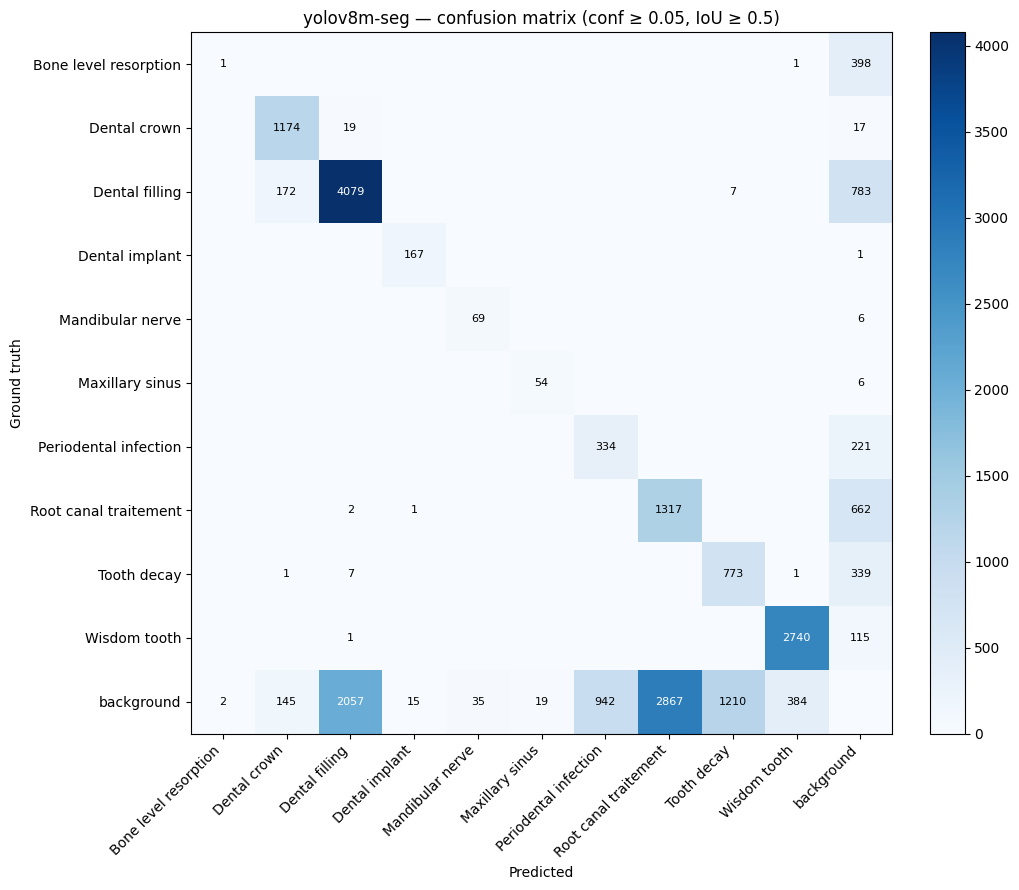


--- Confusion matrix @ conf 0.10 ---


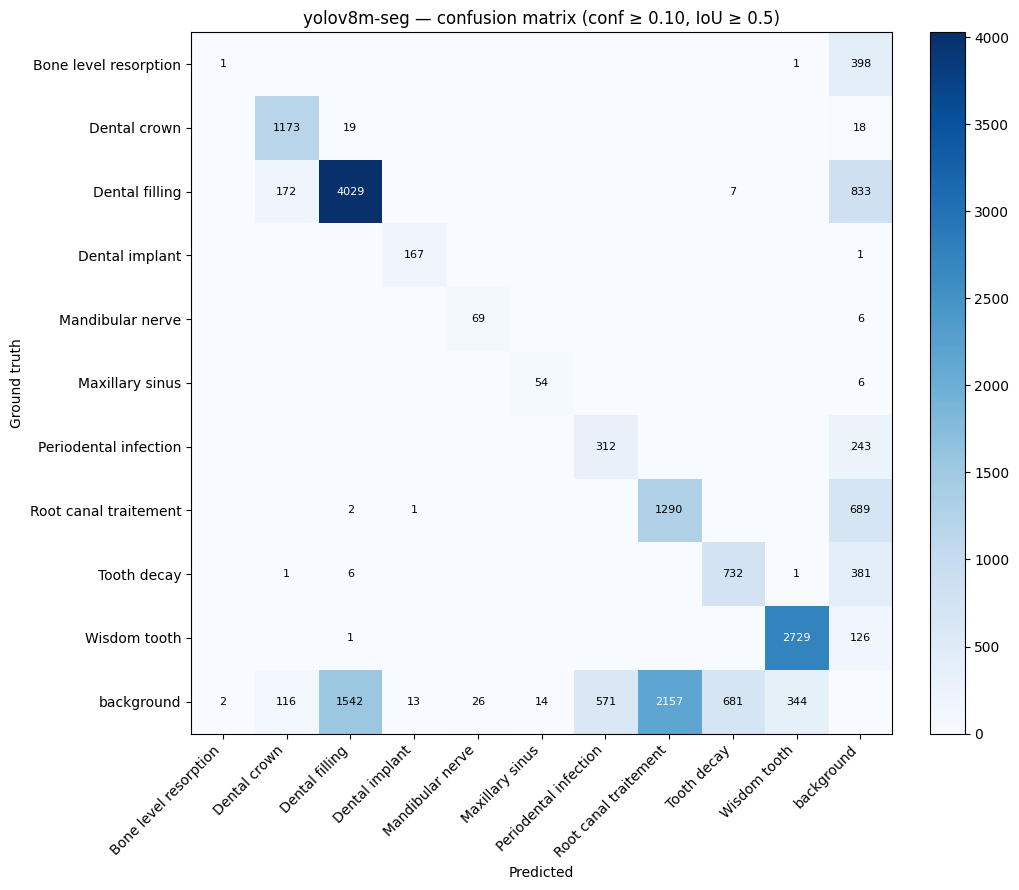


--- Best threshold per class ---
                Class  Best thr  Precision  Recall    F1
       Dental implant     0.150      0.938   0.994 0.965
         Wisdom tooth     0.200      0.897   0.952 0.924
         Dental crown     0.200      0.824   0.974 0.892
      Maxillary sinus     0.150      0.855   0.883 0.869
     Mandibular nerve     0.200      0.788   0.893 0.837
       Dental filling     0.200      0.776   0.791 0.784
          Tooth decay     0.200      0.659   0.610 0.634
Root canal traitement     0.200      0.469   0.627 0.536
Periodental infection     0.200      0.480   0.514 0.496
Bone level resorption     0.150      0.500   0.003 0.005

--- Weak-class error taxonomy @ conf 0.05 ---
                Class   GT   TP  Low-conf TP  Loc err  Missed GT  BG FP
Bone level resorption  400    1            2        0        397      2
Periodental infection  555  334           88      126        133    816
Root canal traitement 1982 1317          110     1632        552   1235
    

RuntimeError: No YOLO class names matched the A4 10-class set.
  This almost always means you attached the STOCK Ultralytics
  checkpoint (80 COCO classes: person, car, dog, ...) instead of
  the dental-finetuned best.pt.
  Model names seen: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign']...
  Expected dental names like: bone level resorption, dental crown, ...
  Fix: point YOLO_CANDIDATE_PATHS at the dental-trained best.pt.

In [13]:
summaries = []
for tag in ["yolov8m-seg", "yolo26n"]:
    s = evaluate_yolo(tag)
    if s is not None:
        summaries.append(s)

## 12 — Final comparison table (Table 6.10 replacement)

Row 1 is the A4 number from the report for reference. Rows 2+ are computed
here under the exact same protocol, so they are now directly comparable.

In [ ]:
A4_REPORTED = {
    "Model":      "A4 (DINOv2+RT-DETR+MaskHead, from report)",
    "Val imgs":   1400,
    "Val objs":   13468,
    "BBox AP":    0.309,
    "BBox AP50":  0.562,
    "BBox AP75":  0.306,
    "BBox AR100": 0.443,
    "Mask AP":    0.118,
    "Mask AP50":  0.347,
    "Mask AP75":  0.041,
    "Mask AR100": 0.173,
}

rows = [A4_REPORTED] + summaries
final_df = pd.DataFrame(rows)
final_df.to_csv(WORK_DIR / "final_comparison.csv", index=False)
print(final_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

### What to paste into the report

- Replace **Table 6.10** in the report with the CSV above.
- Replace the YOLO column in **Table 6.6** (per-class AP) with the per-class
  CSV for `yolov8m-seg` — that gives a like-for-like per-class comparison
  under the same COCOeval protocol A4 used.
- The threshold sweep and weak-class taxonomy for YOLO now exist as CSVs under
  `/kaggle/working/yolo_baseline_eval/<tag>/` so you can drop them in as
  side-by-side tables in Sections 6.4.4 and 6.4.7.

### Expected differences vs the YOLO "0.731 / 0.696" in your recap

Those were Ultralytics' own `model.val()` numbers at that model's default
thresholds. Numbers produced here will usually be **lower** (pycocotools is
stricter), especially for mask AP where the 168×168 encoding cuts some
boundary precision. That's not a bug — it's the same handicap A4 is
evaluated under, which is exactly what we need for a fair comparison.